In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

  Activating project at `~/projects/EccentricBurstTimings`


In [2]:
using EccentricBurstTiming, CairoMakie, CSV, DataFrames, QuadGK
# using Unitful, UnitfulAstro
defaulttheme = Theme(Axis = (xgridvisible=false, ygridvisible=false,
                            yminorticks=IntervalsBetween(4),
                            xminorticks=IntervalsBetween(4),
                            yminorticksvisible=true,
                            xminorticksvisible=true,
                            titlefont = :regular,
                            xminorticksize=3,
                            yminorticksize=3,
                            ylabelsize=20,
                            xlabelsize=20
                            ),
                    Legend = (framevisible=false,),
                    size=(800, 600))
set_theme!(defaulttheme)
update_theme!(theme_latexfonts())

const EBT = EccentricBurstTiming
const DATADIR = joinpath(@__DIR__, "..", "data")

"/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data"

In [ ]:
G_solar = 3.9413556368747037e-7 # R⊙^3 s^-2 M⊙^-1
c_solar = 0.4309220324852666 # R⊙/s

function get_unperturbed_model(;args...)
    args = copy(args)

    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end
    args[:m3] = 0.0

    return  BurstTimingModel(;args...)
end

function get_perturbed_model(;args...)
    args = copy(args)
    
    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end

    return  BurstTimingModel(;args...)
end

function get_models(;args...)

    m = get_unperturbed_model(;args...)
    m_p =  get_perturbed_model(;args...)
    
    return m, m_p
end

function decay_time_s(a0, e0, m1, m2)
    G³ = G_solar^3
    c⁵ = c_solar^5

    β = 64/5*(G³*m1*m2*(m1 + m2))/c⁵
    c0 = a0*(1 - e0^2)/(e0^(12/19))*(1 + 121/304*e0^2)^(-870/2299)
    integral(e) = (e^(29/19)*(1 + (121/304)*e^2)^(1181/2299))/sqrt(1 - e^2)^3

    int, err = quadgk(integral, 0, e0)

    T = 12/19*c0^4/β*int
    return T
end

function orbital_period_s(a, m1, m2)
    return 2π*sqrt(a^3/(G_solar*(m1 + m2)))
end

orbital_period_s (generic function with 1 method)

# Kummer models

In [19]:
function get_kummer_models(filename="GW_advanced_high_density_Z0005.csv"; e_min=0.1)
    filepath = joinpath(DATADIR, "kummer2024", "data_models", filename)
    @assert isfile(filepath) "File $filename not found."

    params = Dict{Int, Dict{Symbol, Float64}}()

    rows = CSV.Rows(filepath)
    for (i, row) in enumerate(rows)
        !iszero(i%2) && continue
        parse(Bool, lowercase(row.merger)) && continue
        e0 = parse(Float64, row.e_in)
        (e0 < e_min) && continue
        a0 = parse(Float64, row.a_in)
        m1, m2 = parse.(Float64, (row.m1, row.m2))
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = parse(Float64, row.incl)
        
        R3 = parse(Float64, row.a_out)
        m3 = parse(Float64, row.m3)
        e3 = parse(Float64, row.e_out)

        ID = parse(Int, row.ID)

        params[ID] = Dict(:e0 => e0, :a0 => a0, :m12 => m12, :m1 => m1, :m2 => m2,
                          :eta => eta, :i0 => i0, :R3 => R3, :m3 => m3, :e3 => e3)
    end

    return params
end

get_kummer_models (generic function with 2 methods)

## Example

┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:175


388144


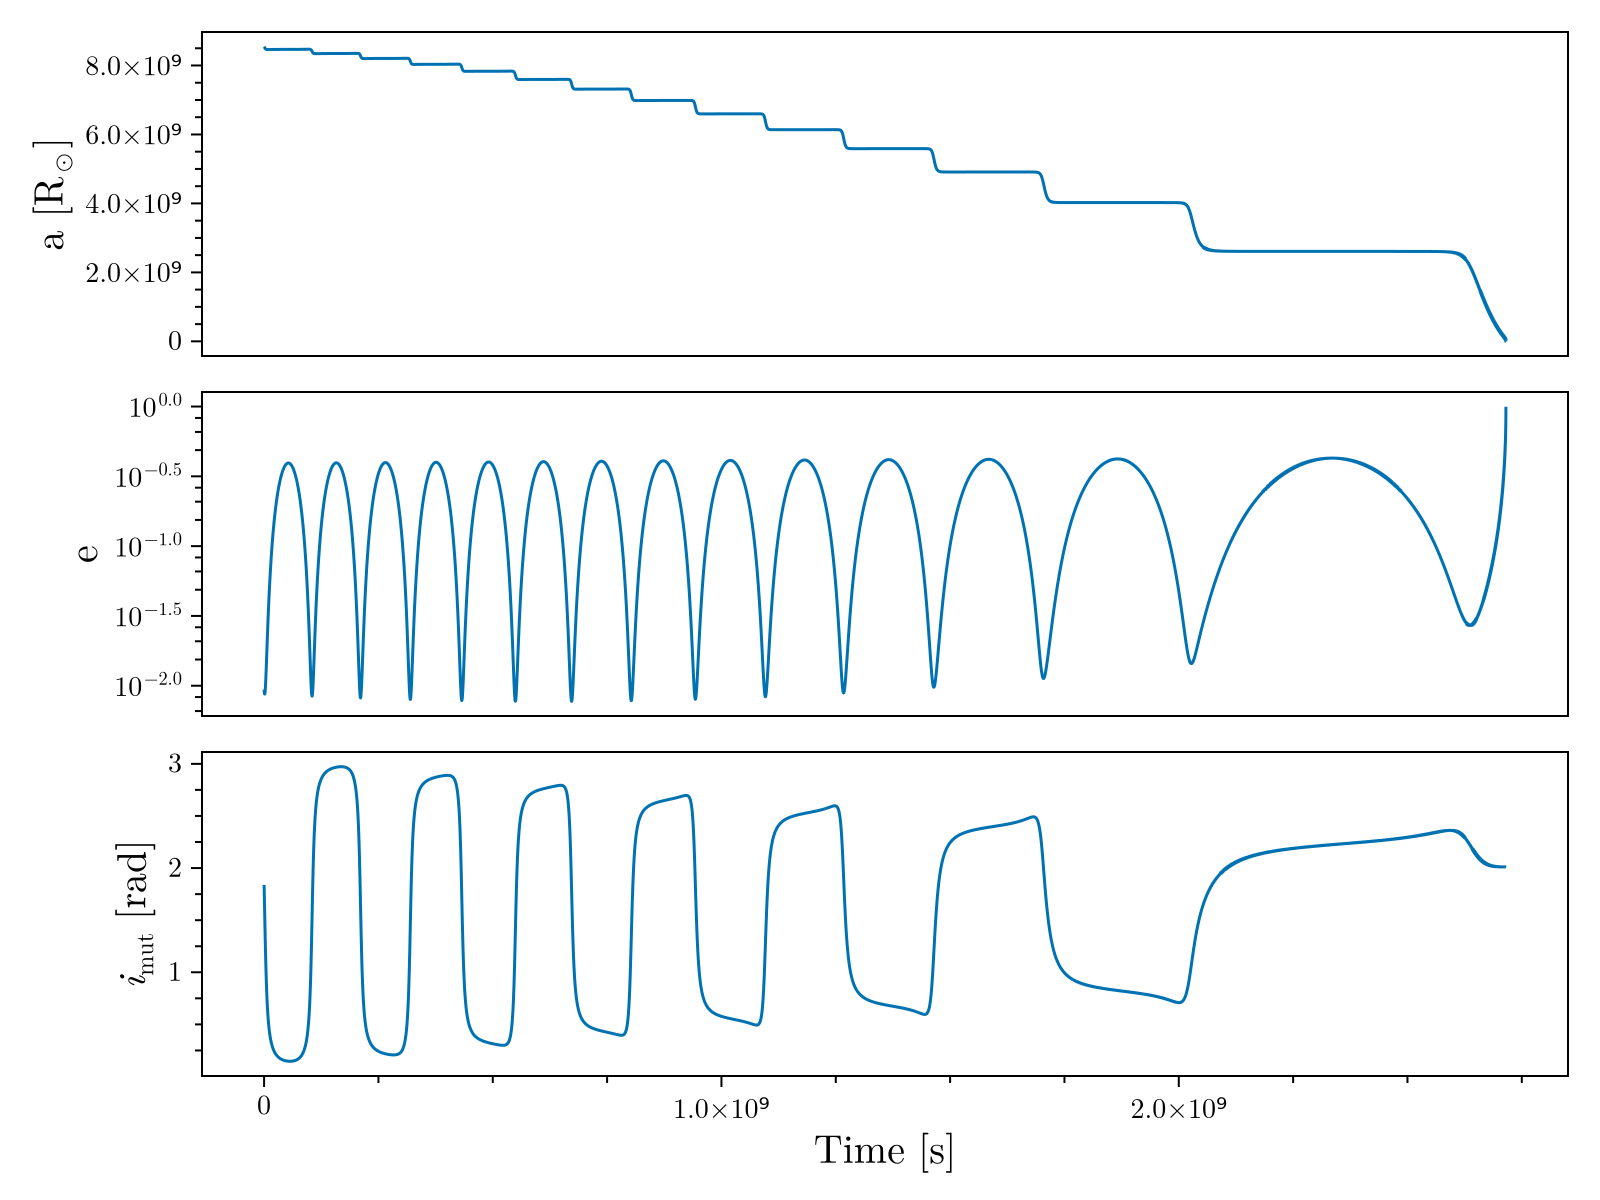

In [ ]:
let models = get_kummer_models(e_min=0.7)
    
    IDs = collect(keys(models))
    
    params = models[IDs[2]]
    m = get_perturbed_model(;params...)
    evolve!(m, 1_000_000, f_GW_max=10, e_min=0.001, verbose=true)
    N = length(m.t)
    println(N)

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax_i = Axis(fig[3, 1], ylabel=L"$i_\text{mut}$ [rad]", xlabel="Time [s]")

    hidexdecorations!(ax)
    hidexdecorations!(ax_e)
    linkxaxes!(ax, ax_e, ax_i)

    t = get_t_array(m, N)
    a = get_a_array(m, N)
    e = get_e_array(m, N)
    i = EBT.get_i_array(m, N)

    lines!(ax, t, a)
    lines!(ax_e, t, 1 .- e)
    lines!(ax_i, t, i)
    fig
end

# Bruenech models

In [7]:
function get_bruenech_models(filename="triple_properties_of_merging_systems.csv"; e_min=0.1)
    filepath = joinpath(DATADIR, "triple_bhbs", filename)
    @assert isfile(filepath) "File $filename not found."

    params = Dict{Int, Dict{Symbol, Float64}}()

    rows = CSV.Rows(filepath)
    for (i, row) in enumerate(rows)
        e0 = parse(Float64, row.e_in)
        (e0 < e_min) && continue
        a0 = parse(Float64, row.a_in)
        m1, m2 = parse.(Float64, (row.m1, row.m2))
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = parse(Float64, row.i_mut)
        
        R3 = parse(Float64, row.a_out)
        R3 < zero(R3) && continue
        m3 = parse(Float64, row.m3)
        e3 = parse(Float64, row.e_out)

        ID = parse(Int, row.ID)

        params[ID] = Dict(:e0 => e0, :a0 => a0, :m12 => m12, :m1 => m1, :m2 => m2,
                          :eta => eta, :i0 => i0, :R3 => R3, :m3 => m3, :e3 => e3)
    end

    return params
end

get_bruenech_models (generic function with 2 methods)

┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:175


956680


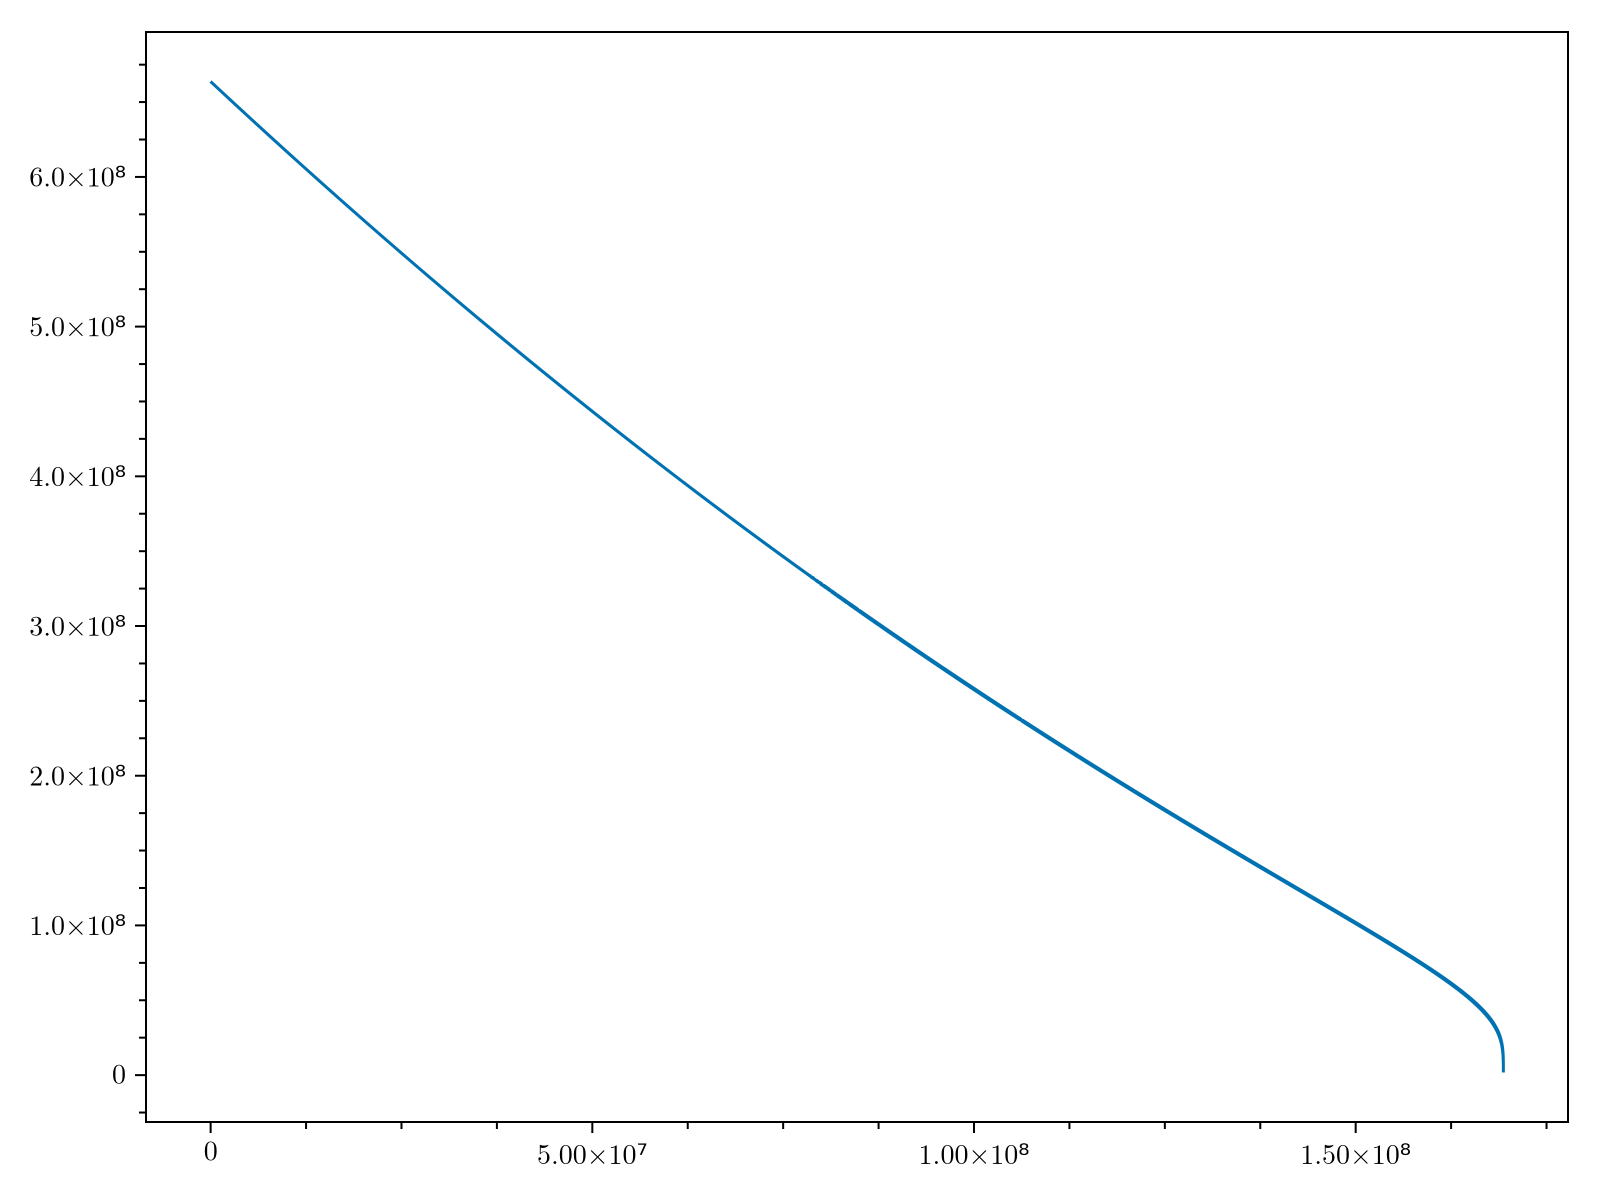

In [13]:
let
    ms = get_bruenech_models()
    IDs = collect(keys(ms))
    
    params = ms[IDs[1]]
    m = get_perturbed_model(;params...)
    evolve!(m, 1_000_000, f_GW_max=10, e_min=0.001, verbose=true)
    N = length(m.t)
    println(N)

    fig = Figure()
    ax = Axis(fig[1, 1])

    t = get_t_array(m, N)
    a = get_a_array(m, N)
    lines!(ax, t, a)
    fig
end

In [61]:
function get_header_arrays(model, N)
    e_array = EBT.get_e_array(model, N)
    a_array = EBT.get_a_array(model, N)
    t_array = EBT.get_t_array(model, N)
    w_array = EBT.get_w_array(model, N)
    V3_array = EBT.get_V3_array(model, N)

    W_array = EBT.get_W_array(model, N)
    i_array = EBT.get_i_array(model, N)

    return e_array, a_array, t_array, w_array, V3_array, W_array, i_array
end


function evolve_and_save_models(filename, model_data; e_min=0.7)

    output_dir = replace(joinpath(DATADIR, "evolution", filename), ".csv" => "")
    !isdir(output_dir) && mkdir(output_dir)
    
    lck = ReentrantLock()
    models = model_data(filename, e_min=e_min)

    IDs = collect(keys(models))
    header = ["time_s", "a_Rsun", "e", "w", "iota", "W", "V3", "fGW"]
    Threads.@threads for ID in IDs
        params = models[ID]

        m, m_pert = get_models(;params...)
        
        outfile = joinpath(output_dir, "$ID.csv")
        let model = m
            evolve!(model, 1_000_000, f_GW_max=10, e_min=0.001)
            N = length(model.t)
            success = EBT.peak_f_GW(model, length(model.t)) > 8


            e, a, t, w, V3, W, i = get_header_arrays(model, N)
            fGWs = map(x -> EBT.peak_f_GW(model, x), 1:N)
            CSV.write(outfile, Tables.table([t a e w i W V3 fGWs]), header=header)
        end

        let model = m_pert
            evolve!(model, 1_000_000, f_GW_max=10, e_min=0.001)
            N = length(model.t)
            success = EBT.peak_f_GW(model, length(model.t)) > 8

            outfile = replace(outfile, ".csv" => "_pert.csv")

            e, a, t, w, V3, W, i = get_header_arrays(model, N)
            fGWs = map(x -> EBT.peak_f_GW(model, x), 1:N)
            CSV.write(outfile, Tables.table([t a e w i W V3 fGWs]), header=header)

        end
    end
end

evolve_and_save_models (generic function with 1 method)

In [62]:
evolve_and_save_models("GW_advanced_high_density_Z0005.csv", get_kummer_models)

In [77]:
evolve_and_save_models("triple_properties_of_merging_systems.csv", get_bruenech_models)

In [ ]:
let f = "../data/evolution/triple_properties_of_merging_systems/1.csv"
    # f = CSV.Rows()
    # f[:,1]
    CSV.File(f, select=["time_s", "e"])
end

184480-element SentinelArrays.ChainedVector{Float64, Vector{Float64}}:
 0.9683674408792674
 0.968364087454474
 0.968360734023298
 0.9683573805857392
 0.9683540271417975
 0.9683506736914729
 0.9683473202347653
 0.9683439667716748
 0.9683406133022013
 0.9683372598263447
 ⋮
 0.008126385078834723
 0.008073961896803365
 0.008021342565257461
 0.007968524326724786
 0.007915504355997128
 0.007862279757740783
 0.007808847563996637
 0.007755204731563516
 0.007701348139258024

In [82]:
function plot_evolution(filepath; loge=true)

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=loge ? log10 : identity)
    ax_i = Axis(fig[3, 1], ylabel=L"$i_\text{mut}$ [rad]", xlabel="Time [s]")

    hidexdecorations!(ax)
    hidexdecorations!(ax_e)
    linkxaxes!(ax, ax_e, ax_i)

    let fl = CSV.File(filepath, select=["time_s", "e", "a_Rsun", "iota", "fGW"])
        t = fl.time_s
        a = fl.a_Rsun
        e = fl.e
        # i = fl.iota

        t = t ./ t[end]

        lines!(ax, t, a)
        lines!(ax_e, t, loge ? 1 .- e : e)
        # lines!(ax_i, t, i)

    end

    let fl = CSV.File(replace(filepath, ".csv" => "_pert.csv"), select=["time_s", "e", "a_Rsun", "iota", "fGW"])
        t = fl.time_s
        a = fl.a_Rsun
        e = fl.e
        i = fl.iota

        i_lims = extrema(i)
        ylims!(ax_i, 0.9i_lims[1], 1.1i_lims[2])

        t = t ./ t[end]

        lines!(ax, t, a, color=Makie.wong_colors()[2])
        lines!(ax_e, t, loge ? 1 .- e : e, color=Makie.wong_colors()[2])
        lines!(ax_i, t, i, color=Makie.wong_colors()[2])

    end
    fig
end

plot_evolution (generic function with 1 method)

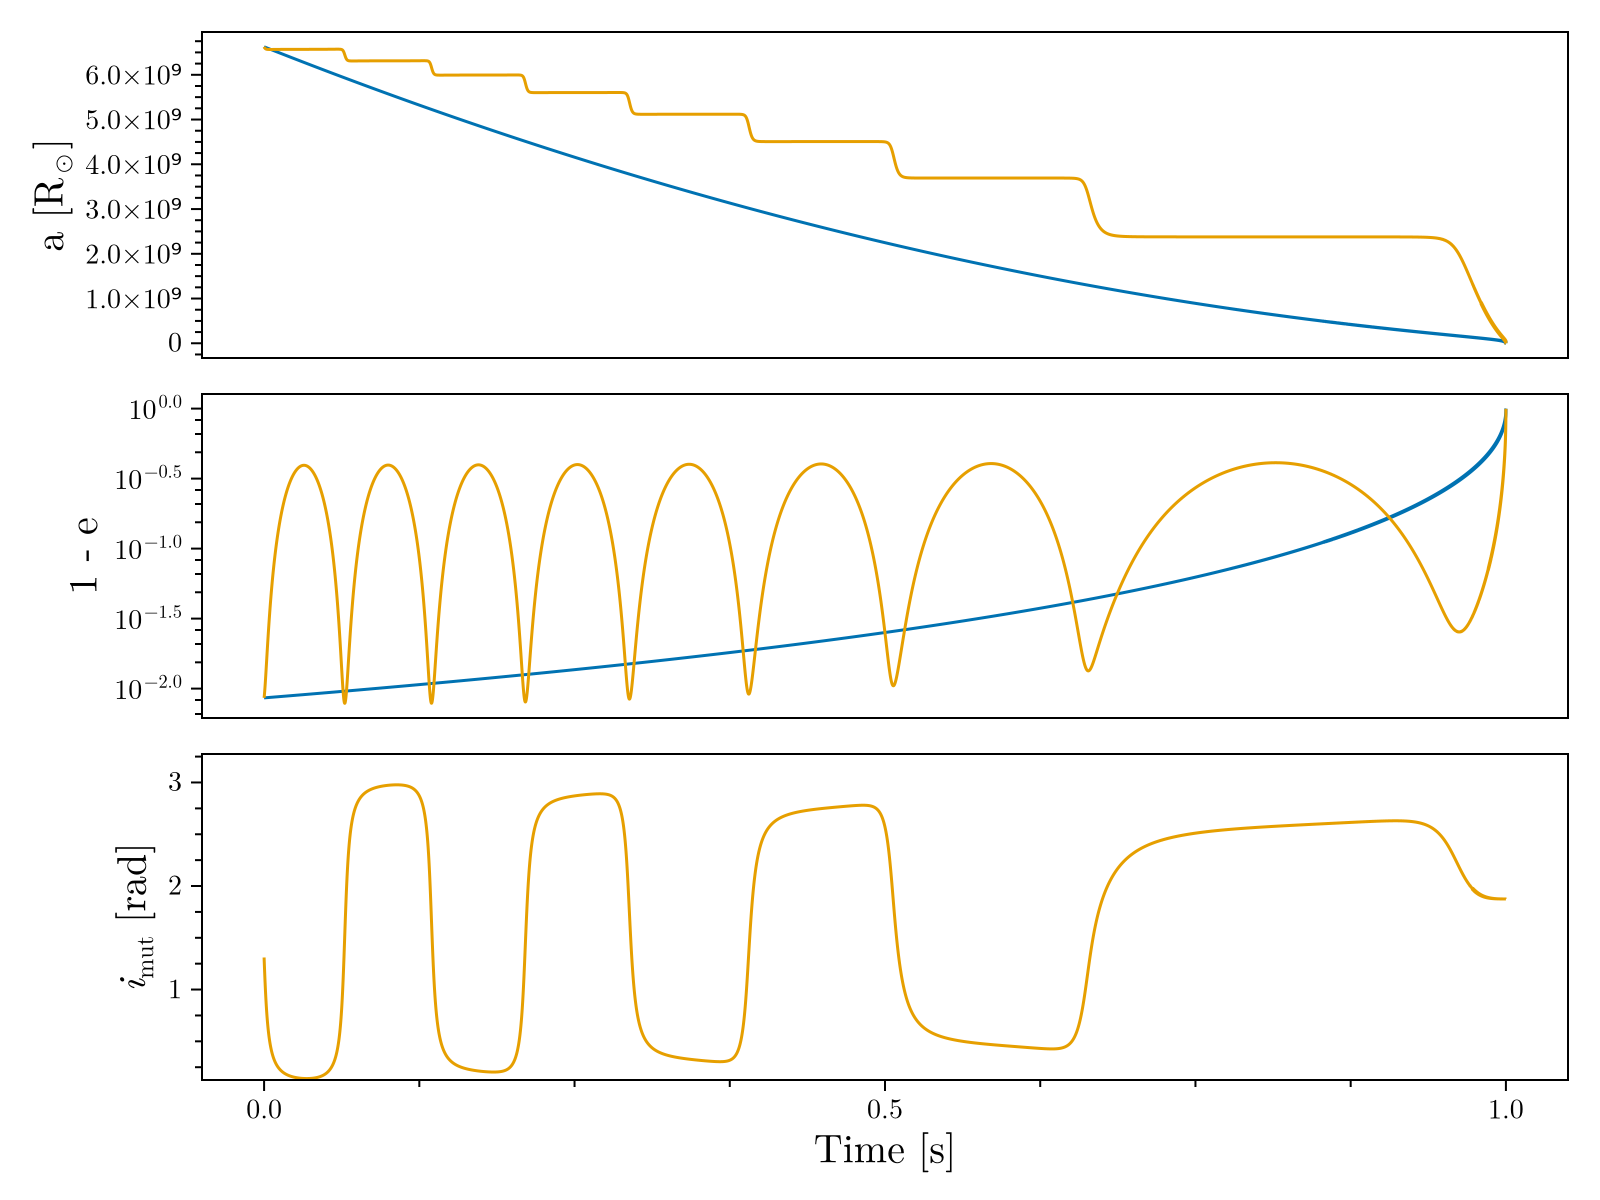

In [83]:
plot_evolution("../data/evolution/GW_advanced_high_density_Z0005/9880.csv")

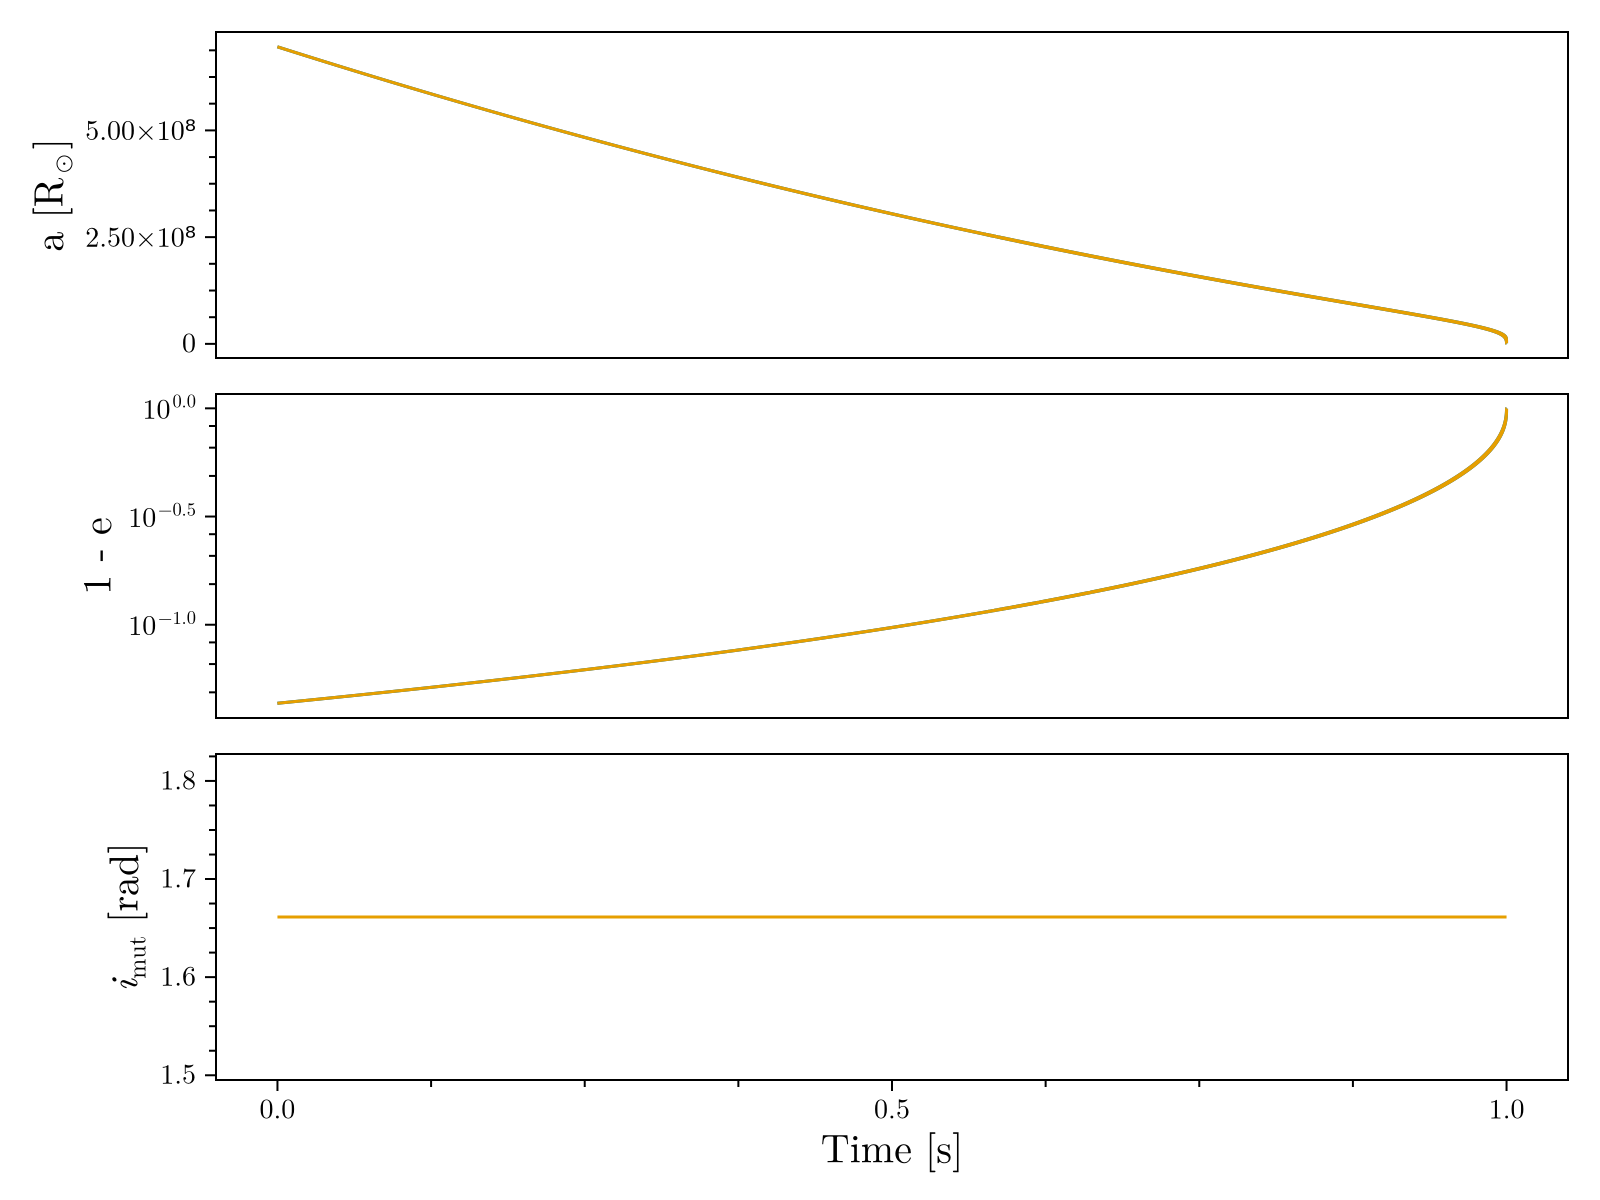

In [84]:
plot_evolution("../data/evolution/triple_properties_of_merging_systems/99.csv", loge=true) 